In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pandas import Timedelta
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt
import copy
import random
import warnings
warnings.filterwarnings('ignore')

# random seeds
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [3]:
# MLP config
class Config_MLP:
    #BIC toggle
    use_bic: bool = True
    max_bic_lag = 44

    # Network architecture
    hidden_layers = [128, 64, 32]

    # parameters
    learning_rate = 0.001
    batch_size = 1024
    epochs = 100
    early_stopping_rounds = 10
    n_ensembles = 10

    # Data parameters
    initial_train_years = 5
    validation_years = 1
    test_months = 12

    # Lag candidates
    lag_candidates = [1, 5, 22]

    # Transformation parameters
    use_log_transform = True  # model log(RV) instead of rv directly
    target_scaler = True  # scale target variable

    device = torch.device('cpu') #default to cpu
    print("Using CPU")

Using CPU


In [51]:
# LSTM Config
class Config_LSTM:
    #BIC toggle
    use_bic: bool = False
    max_bic_lag = 44

    # Network architecture
    hidden_layers = [16,8]

    # Training parameters
    learning_rate = 0.001
    batch_size = 512
    epochs = 100
    early_stopping_rounds = 10
    n_ensembles = 10

    # Data parameters
    initial_train_years = 5
    validation_years = 1
    test_months = 12

    # Lag candidates
    lookback_period = 22
    lag_candidates = sorted(list(range(1, lookback_period + 1)), reverse = True)

    # Transformation parameters
    use_log_transform = True  # model log(RV) instead of rv directly
    target_scaler = True  # scale target variable

    # Device
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("Using CUDA")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS")
    else:
        device = torch.device('cpu')
        print("Using CPU")

Using CUDA


In [5]:
class MLPWithBatchNorm(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super(MLPWithBatchNorm, self).__init__()

        layers = []
        prev_dim = input_dim

        # Build hidden layers with batch normalization
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.4))
            prev_dim = hidden_dim

        # Output layer - NO activation
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [6]:
class LSTMWithBatchNorm(nn.Module):
    def __init__(self, input_dim: int, hidden_layers, dropout: float = 0.0):
        super().__init__()

        self.input_dim = int(input_dim)  # number of lags
        self.hidden_layers = list(hidden_layers)
        self.dropout = float(dropout)

        # Build LSTM stack
        self.lstm_layers = nn.ModuleList()
        # First LSTM layer: input_size=1 (lag value), hidden_size=hidden_layers[0]
        self.lstm_layers.append(nn.LSTM(
            input_size=1,
            hidden_size=self.hidden_layers[0],
            num_layers=1,
            batch_first=True
        ))

        # Additional LSTM layers if provided
        for in_size, out_size in zip(self.hidden_layers[:-1], self.hidden_layers[1:]):
            self.lstm_layers.append(nn.LSTM(
                input_size=in_size,
                hidden_size=out_size,
                num_layers=1,
                batch_first=True
            ))

        # Optional dropout
        self.use_dropout = self.dropout > 0.0
        if self.use_dropout:
            self.dropout_layer = nn.Dropout(self.dropout)

        # BatchNorm over the final hidden size
        last_hidden = self.hidden_layers[-1]
        self.bn = nn.BatchNorm1d(last_hidden)

        # Final linear to 1-d output
        self.fc_out = nn.Linear(last_hidden, 1)

        # Initialize the output layer
        nn.init.kaiming_uniform_(self.fc_out.weight, a=np.sqrt(5))
        if self.fc_out.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.fc_out.weight)
            bound = 1 / np.sqrt(fan_in)
            nn.init.uniform_(self.fc_out.bias, -bound, bound)

    def forward(self, x):
        if x.dim() == 2:
            # (N, num_lags) -> (N, seq_len=num_lags, 1)
            x = x.unsqueeze(-1)
        elif x.dim() == 3:
            # already (batch, seq_len, input_size)
            pass
        else:
            raise ValueError(f"Expected input of shape (N, L) or (N, L, C), got {tuple(x.shape)}")

        # Pass through LSTM stack
        for lstm in self.lstm_layers:
            x, _ = lstm(x)  # x: (batch, seq_len, hidden_size)

        # Last time step
        last = x[:, -1, :]  # (batch, hidden_size)

        # BatchNorm + optional dropout
        last = self.bn(last)
        if self.use_dropout:
            last = self.dropout_layer(last)

        out = self.fc_out(last)  # (batch, 1)
        return out

In [7]:
# Data parsing
def load_and_prepare_data(filepath):
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min()} to {rv.index.max()}")

    return rv

def create_lagged_features(data, lags):
    df = data.copy()

    # Create lagged features
    for lag in lags:
        df[f'lag_{lag}'] = df['RV_daily'].shift(lag)

    # Remove rows with NaN values (from lagging)
    df = df.dropna()

    return df

def prepare_train_val_test_data(df, train_start, train_end, val_end, test_end): #split into train, val, test
    train_data = df[train_start:train_end]
    val_data = df[train_end:val_end]
    test_data = df[val_end:test_end]

    return train_data, val_data, test_data

In [8]:
# Calculate BIC
def calculate_BIC(val_data, max_lag: int = 44):
    bic_values = {}
    for lag in range(2, max_lag + 1):
        model = AutoReg(val_data, lags=lag, old_names=False)
        result = model.fit()
        bic_values[lag] = result.bic

    best_lag = min(bic_values, key=bic_values.get)

    chosen = [1]

    if best_lag > 10:
        second_var = int(best_lag * 5/22)
        chosen.append(second_var)
        chosen.append(best_lag)
    else:
        second_var = round(best_lag * 22/5)
        chosen.append(best_lag)
        chosen.append(second_var)

    # keep sorted by size for stable column ordering
    #if Config_MLP:
        #chosen = sorted(chosen)
        #print(f"BIC-selected lag set: {chosen}")
    #if Config_LSTM:
    chosen = sorted(list(range(1, chosen[-1]+1)), reverse = True)
    print(f"BIC-selected lookback period: {chosen}")
    return chosen

In [9]:
# Training
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_single_model(X_train, y_train, X_val, y_val, config, verbose=False):
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(config.device)
    y_train_tensor = torch.FloatTensor(y_train).to(config.device)
    X_val_tensor = torch.FloatTensor(X_val).to(config.device)
    y_val_tensor = torch.FloatTensor(y_val).to(config.device)

    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True) #drop_last = True)

    # Initialize model
    model_cls = LSTMWithBatchNorm if isinstance(config, Config_LSTM) else MLPWithBatchNorm
    model = model_cls(X_train.shape[1], config.hidden_layers).to(config.device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

    # Early stopping
    early_stopping = EarlyStopping(patience=config.early_stopping_rounds)

    # Track best weights
    best_val   = float('inf')
    best_state = None
    best_epoch = 0

    # Training loop
    train_losses = []
    val_losses = []

    for epoch in range(config.epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            out  = model(batch_X)
            loss = criterion(out, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) #gradient clipping?
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / max(1, len(train_loader))
        train_losses.append(avg_train_loss)

        # # Validation phase
        model.eval()
        with torch.inference_mode():
            vout  = model(X_val_tensor)
            vloss = criterion(vout, y_val_tensor).item()
        val_losses.append(vloss)

        if (best_val - vloss) > early_stopping.min_delta:
            best_val   = vloss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        #Early stopping
        early_stopping(vloss)
        if early_stopping.early_stop:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}; best={best_epoch} val={best_val:.6f}")
            break

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config.epochs}  Train: {avg_train_loss:.6f}  Val: {vloss:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses

def set_seed_all(seed): # for random ensemble
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_ensemble(X_train, y_train, X_val, y_val, config): #better ensemble trainer
    models = []
    base_seed = 42
    print(f"Training ensemble of {config.n_ensembles} models...")
    for i in range(config.n_ensembles):
        print(f"Training model {i+1}/{config.n_ensembles}")
        set_seed_all(base_seed + i)
        model, _, _ = train_single_model(X_train, y_train, X_val, y_val, config, verbose=False)
        models.append(model)
    return models

def predict_ensemble(models, X, config): #make prediction using ensembles
    X_tensor = torch.FloatTensor(X).to(config.device)
    predictions = []

    for model in models:
        model.eval()
        with torch.no_grad():
            predictions.append(model(X_tensor).cpu().numpy())

    # Average predictions
    return np.stack(predictions, axis=0)

In [10]:
# Metrics
def calculate_mse(y_true, y_pred): #MSE
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true, y_pred):
    y_true = np.maximum(y_true, 1e-8) #ensure non zero
    y_pred = np.maximum(y_pred, 1e-8)

    # QLIKE formula
    qlike = np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)
    return qlike

In [11]:
# Expanding window
def expanding_window_forecast(rv_data, config):
    # Create lagged features
    if config.use_bic:
        df_with_lags = create_lagged_features(rv_data, list(range(1, config.max_bic_lag + 1)))
    else:
        df_with_lags = create_lagged_features(rv_data, config.lag_candidates)

    # Initialize results storage
    all_results = []

    # Get feature columns when not using BIC (fixed set)
    if not config.use_bic:
        feature_cols = [col for col in df_with_lags.columns if col.startswith('lag_')]

    # Start date for expanding window
    start_date = df_with_lags.index[0]
    initial_train_end = start_date + pd.DateOffset(years=config.initial_train_years)

    # Find the first valid test start date
    current_test_start = initial_train_end + pd.DateOffset(years=config.validation_years)

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training period: {start_date.date()} to {initial_train_end.date()}")
    print(f"Using log transformation: {config.use_log_transform}")
    print(f"Using target scaling: {config.target_scaler}")

    window_count = 0

    while current_test_start < df_with_lags.index[-1]:
        window_count += 1

        # Define periods
        train_end = current_test_start - pd.DateOffset(years=config.validation_years)
        val_start = train_end + Timedelta(days=1)
        val_end = current_test_start + Timedelta(days=1)
        test_end = min(current_test_start + pd.DateOffset(months=config.test_months),
                       df_with_lags.index[-1]) + Timedelta(days=2)

        # Get data splits
        train_data = df_with_lags[start_date:train_end]
        val_data = df_with_lags[val_start:val_end]
        test_data = df_with_lags[val_end + Timedelta(days=1):test_end]

        if len(test_data) == 0:
            break

        print(f"\n--- Window {window_count} ---")
        print(f"Train: {start_date.date()} to {train_end.date()} ({len(train_data)} obs)")
        print(f"Val: {val_start.date()} to {val_end.date()} ({len(val_data)} obs)")
        print(f"Test: {val_end.date() + Timedelta(days=1)} to {test_end.date()} ({len(test_data)} obs)")

        # Select lag set for this window
        if config.use_bic:
            bic_lags = calculate_BIC(val_data['RV_daily'])
            current_feature_cols = [f'lag_{lag}' for lag in bic_lags]
        else:
            current_feature_cols = feature_cols

        # Prepare features
        X_train = train_data[current_feature_cols].values
        X_val = val_data[current_feature_cols].values
        X_test = test_data[current_feature_cols].values

        # Prepare targets with optional log transformation
        y_train_original = train_data['RV_daily'].values.reshape(-1, 1)
        y_val_original = val_data['RV_daily'].values.reshape(-1, 1)
        y_test_original = test_data['RV_daily'].values.reshape(-1, 1)

        if config.use_log_transform:
            # Apply log transformation to targets
            y_train = np.log(y_train_original + 1e-8)
            y_val = np.log(y_val_original + 1e-8)
            y_test = np.log(y_test_original + 1e-8)
        else:
            y_train = y_train_original.copy()
            y_val = y_val_original.copy()
            y_test = y_test_original.copy()

        # Standardize features
        feature_scaler = StandardScaler()
        X_train_scaled = feature_scaler.fit_transform(X_train)
        X_val_scaled = feature_scaler.transform(X_val)
        X_test_scaled = feature_scaler.transform(X_test)

        # Optionally scale targets
        if config.target_scaler:
            target_scaler = StandardScaler()
            y_train_scaled = target_scaler.fit_transform(y_train)
            y_val_scaled = target_scaler.transform(y_val)
        else:
            y_train_scaled = y_train
            y_val_scaled = y_val
            target_scaler = None

        # Train ensemble
        models = train_ensemble(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, config)

        # 1) get per-model outputs (scaled log-space if you used target_scaler/use_log_transform)
        train_pred_scaled_all = predict_ensemble(models, X_train_scaled, config)
        test_pred_scaled_all  = predict_ensemble(models,  X_test_scaled,  config)

        # 2) inverse target scaling to LOG space (if used)
        if config.target_scaler and target_scaler is not None:
            train_log_all = np.stack([target_scaler.inverse_transform(p) for p in train_pred_scaled_all], axis=0)
            test_log_all  = np.stack([target_scaler.inverse_transform(p)  for p in test_pred_scaled_all],  axis=0)
        else:
            train_log_all, test_log_all = train_pred_scaled_all, test_pred_scaled_all

        # 3) undo the log, then ARITHMETIC mean in original RV space
        if config.use_log_transform:
            train_pred = np.mean(np.exp(train_log_all), axis=0)
            test_pred  = np.mean(np.exp(test_log_all),  axis=0)
        else:
            train_pred = np.mean(train_log_all, axis=0)
            test_pred  = np.mean(test_log_all,  axis=0)

        # (optional) tiny floor for numerical stability
        eps = 1e-12
        train_pred = np.maximum(train_pred, eps)
        test_pred  = np.maximum(test_pred,  eps)

        # Calculate metrics using original scale
        train_mse = calculate_mse(y_train_original, train_pred)
        test_mse = calculate_mse(y_test_original, test_pred)
        train_qlike = calculate_qlike(y_train_original.flatten(), train_pred.flatten())
        test_qlike = calculate_qlike(y_test_original.flatten(), test_pred.flatten())

        print(f"In-sample MSE: {train_mse:.6f}, QLIKE: {train_qlike:.6f}")
        print(f"Out-of-sample MSE: {test_mse:.6f}, QLIKE: {test_qlike:.6f}")

        # Store results
        for i, date in enumerate(test_data.index):
            all_results.append({
                'ticker': 'SPY',
                'date': date,
                'real_RV': y_test_original[i, 0],
                'predicted_RV': test_pred[i, 0],
                'window': window_count,
                'train_mse': train_mse,
                'test_mse': test_mse,
                'train_qlike': train_qlike,
                'test_qlike': test_qlike,
                'lags_used': [str(current_feature_cols)]
            })

        # Move to next window (12 months forward)
        current_test_start = current_test_start + pd.DateOffset(months=config.test_months)

    return pd.DataFrame(all_results)

In [12]:
# Visualisation
def plot_results(results_df):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realised Volatility')
    ax1.set_title('Actual vs Predicted Realised Volatility')

    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Scatter plot
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)

    # diagonal line
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect Prediction')

    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Actual vs Predicted RV (Scatter Plot)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig('mlp_rv_forecast_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df): #summary statistics of evaluation metrics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

In [ ]:
# MLP
def main_mlp(): #run for MLP forecast
    print("="*60)
    print("MLP NEURAL NETWORK")
    print("="*60)

    # Initialize configuration
    config = Config_MLP()
    print(f"\nUsing device: {config.device}")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('XLY.csv')

    # Run expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    if config.use_bic:
        output_filename = 'MLP BIC.csv'
    else:
        output_filename = 'MLP.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_mlp()

LSTM NEURAL NETWORK

Using device: cuda

Loading data...
Data loaded: 6105 observations
Date range: 1999-01-04 00:00:00 to 2025-04-29 00:00:00

Starting expanding window forecasting...
Initial training period: 1999-02-09 to 2004-02-09
Using log transformation: True
Using target scaling: True

--- Window 1 ---
Train: 1999-02-09 to 2004-02-09 (860 obs)
Val: 2004-02-10 to 2005-02-10 (254 obs)
Test: 2005-02-11 to 2006-02-11 (252 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model 4/10
Training model 5/10
Training model 6/10
Training model 7/10
Training model 8/10
Training model 9/10
Training model 10/10
In-sample MSE: 0.011507, QLIKE: 0.406402
Out-of-sample MSE: 0.001013, QLIKE: 0.068637

--- Window 2 ---
Train: 1999-02-09 to 2005-02-09 (1113 obs)
Val: 2005-02-10 to 2006-02-10 (253 obs)
Test: 2006-02-11 to 2007-02-11 (250 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training 

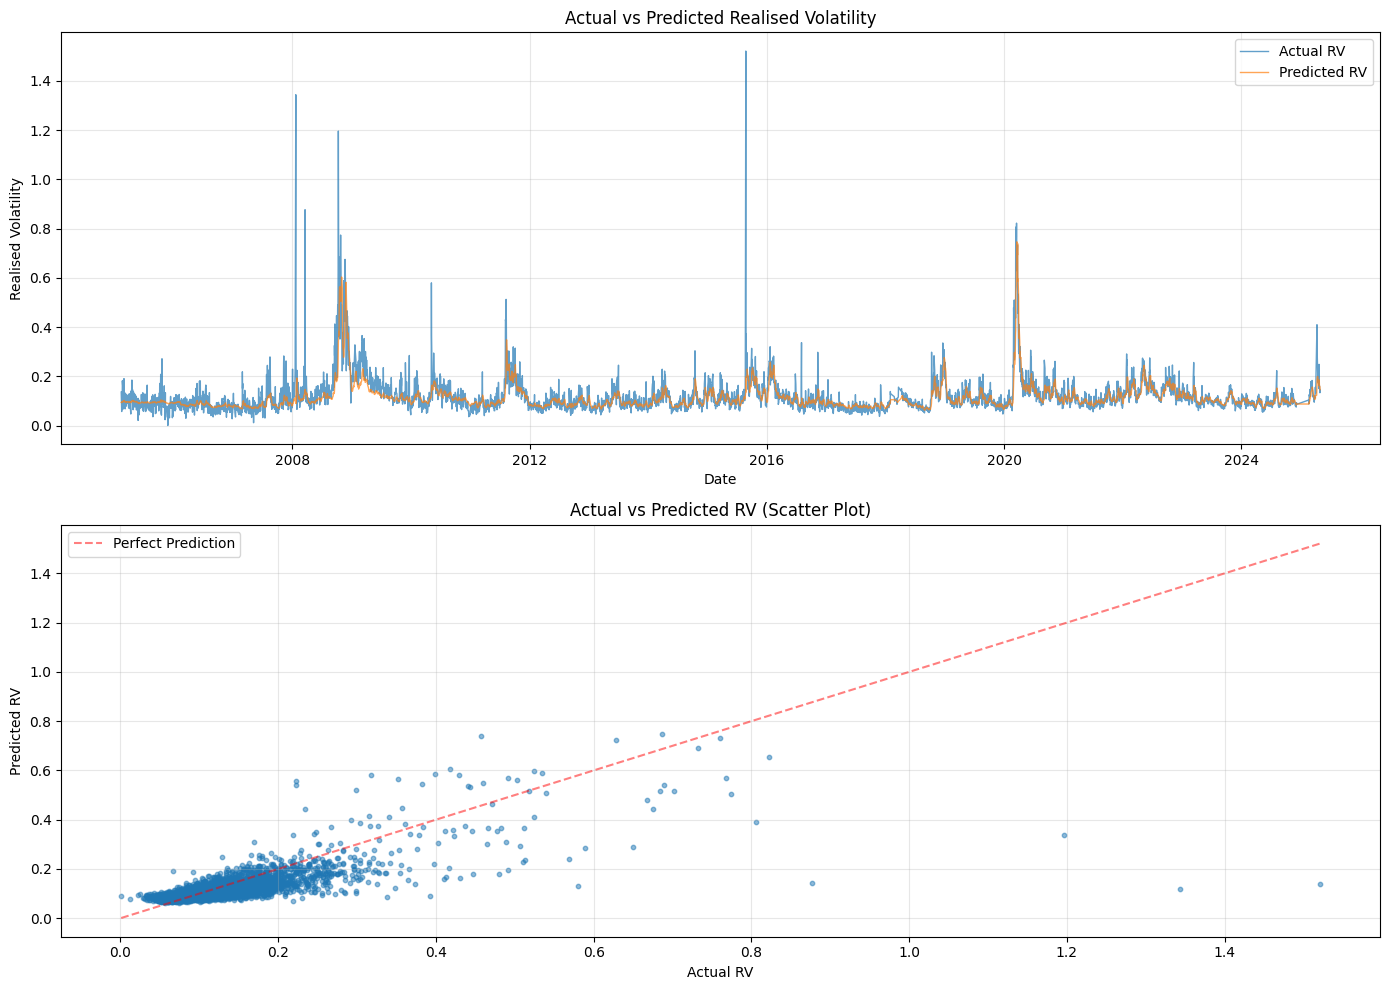

In [52]:
# LSTM
def main_lstm(): #run for lstm forecast
    print("="*60)
    print("LSTM NEURAL NETWORK")
    print("="*60)

    # Initialize configuration
    config = Config_LSTM()
    print(f"\nUsing device: {config.device}")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('XLV.csv')

    # Run expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    if config.use_bic:
        output_filename = 'LSTM {XLV} BIC.csv'
    else:
        output_filename = 'LSTM {XLV}.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_lstm()